# E-Commerce Customer & Sales Analysis

## 1. Project Overview

This project analyzes transactional data from an online retail business to understand sales performance, customer behavior, product performance, geographic revenue contribution, and cancellation patterns.

The objective is to transform raw transactional data into meaningful business insights using Python, Pandas, NumPy, and Matplotlib.

## 2. Dataset Description

The dataset contains transactional records from an online retail business operating primarily in the United Kingdom.

Each row represents a product-level transaction and includes information such as invoice number, product code, product description, quantity purchased, invoice date, unit price, customer ID, and country.

The dataset contains transactions across multiple countries and includes both completed and cancelled orders.

This project focuses on analyzing valid completed sales while preserving cancelled transactions separately for cancellation analysis.

| Column | Description |
|---|---|
| InvoiceNo | Unique invoice or transaction identifier |
| StockCode | Product identifier |
| Description | Product name |
| Quantity | Number of units purchased |
| InvoiceDate | Date and time of the transaction |
| UnitPrice | Price per unit |
| CustomerID | Unique customer identifier |
| Country | Customer's country |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [ ]:
df = pd.read_excel("/content/Online Retail.xlsx")

## 3. Data Understanding

### 3.1 Dataset Preview

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### 3.2 Dataset Shape and Columns

In [ ]:
df.shape

(541909, 8)

In [ ]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

### 3.3 Data Types and Summary Statistics

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


## 4. Data Quality Assessment

### 4.1 Missing Values

In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135037
Country,0
IsCancelled,0


In [ ]:
#missing valu percentage
(df.isnull().sum()/len(df))*100

,0
InvoiceNo,0.000000
StockCode,0.000000
Description,0.268311
Quantity,0.000000
InvoiceDate,0.000000
UnitPrice,0.000000
CustomerID,24.926694
Country,0.000000


### 4.2 Duplicate Records

In [ ]:
# Duplicate rows
df.duplicated().sum()

np.int64(5268)

### 4.3 Invalid Quantities and Prices

In [ ]:
# Negative quantity
(df["Quantity"] < 0).sum()

np.int64(10624)

In [ ]:
# Zero or negative UnitPrice
(df["UnitPrice"] <= 0).sum()

np.int64(2517)

### 4.4 Cancellation Check

In [ ]:
# Cancellation invoices
df[df["InvoiceNo"].astype(str).str.startswith("C")].shape

(9288, 8)

### 4.5 Unique Customers and Countries

In [ ]:
# Unique customers
df["CustomerID"].nunique()

4372

In [ ]:
# Unique countries
df["Country"].nunique()

38

## 5. Data Cleaning

### 5.1 Remove Exact Duplicates

In [ ]:
df[df.duplicated()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
587,536412,22273,FELTCRAFT DOLL MOLLY,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
589,536412,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,1,2010-12-01 11:49:00,3.75,17920.0,United Kingdom
594,536412,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,2010-12-01 11:49:00,2.10,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
600,536412,22569,FELTCRAFT CUSHION BUTTERFLY,2,2010-12-01 11:49:00,3.75,17920.0,United Kingdom


In [ ]:
raw_df = df.copy()

In [ ]:
df = df.drop_duplicates().copy()

In [ ]:
df.duplicated().sum()

np.int64(0)

### 5.2 Handle Missing Customer IDs

In [ ]:
df["CustomerID"].isnull().sum()

np.int64(135037)

### 5.3 Separate Cancelled Transactions

In [ ]:
df["IsCancelled"] = df["InvoiceNo"].astype(str).str.startswith("C")

In [ ]:
df["IsCancelled"].value_counts()

,count
IsCancelled,
False,527390
True,9251


In [ ]:
cancelled_orders = df[df["IsCancelled"] == True].copy()

In [ ]:
valid_sales = df[df["IsCancelled"] == False].copy()

### 5.4 Remove Invalid Sales Transactions

In [ ]:
valid_sales[valid_sales["Quantity"] <= 0].shape

(1336, 9)

In [ ]:
valid_sales[valid_sales["UnitPrice"] <= 0].shape

(2512, 9)

In [ ]:
valid_sales = valid_sales[
    (valid_sales["Quantity"] > 0) &
    (valid_sales["UnitPrice"] > 0)
].copy()

## 6. Feature Engineering

### 6.1 Revenue Feature

In [ ]:
valid_sales["Revenue"] = (
    valid_sales["Quantity"] * valid_sales["UnitPrice"]
)

In [ ]:
valid_sales[
    ["Quantity", "UnitPrice", "Revenue"]
].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


### 6.2 Date and Time Features

In [ ]:
valid_sales["InvoiceDate"] = pd.to_datetime(valid_sales["InvoiceDate"])

In [ ]:
valid_sales["Year"] = valid_sales["InvoiceDate"].dt.year
valid_sales["Month"] = valid_sales["InvoiceDate"].dt.month
valid_sales["YearMonth"] = (
    valid_sales["InvoiceDate"]
    .dt.to_period("M")
)
valid_sales["MonthName"] = valid_sales["InvoiceDate"].dt.month_name()
valid_sales["Day"] = valid_sales["InvoiceDate"].dt.day
valid_sales["Weekday"] = valid_sales["InvoiceDate"].dt.day_name()
valid_sales["Hour"] = valid_sales["InvoiceDate"].dt.hour

In [ ]:
valid_sales.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,Revenue,Year,Month,YearMonth,MonthName,Day,Weekday,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,15.30,2010,12,2010-12,December,1,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,2010,12,2010-12,December,1,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,22.00,2010,12,2010-12,December,1,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,2010,12,2010-12,December,1,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,2010,12,2010-12,December,1,Wednesday,8


### 6.3 Customer-Level Dataset

In [74]:
customer_sales = valid_sales.dropna(
    subset=["CustomerID"]
).copy()

In [75]:
customer_sales["CustomerID"] = (
    customer_sales["CustomerID"].astype("Int64")
)

In [ ]:
print("Raw dataset:", raw_df.shape)
print("After duplicate removal:", df.shape)
print("Cancelled transactions:", cancelled_orders.shape)
print("Valid sales:", valid_sales.shape)
print("Customer sales:", customer_sales.shape)

print(
    "Remaining duplicates:",
    valid_sales.duplicated().sum()
)

print(
    "Invalid quantity:",
    (valid_sales["Quantity"] <= 0).sum()
)

print(
    "Invalid price:",
    (valid_sales["UnitPrice"] <= 0).sum()
)

Raw dataset: (541909, 8)
After duplicate removal: (536641, 9)
Cancelled transactions: (9251, 9)
Valid sales: (524878, 17)
Customer sales: (392692, 17)
Remaining duplicates: 0
Invalid quantity: 0
Invalid price: 0


## 7. Exploratory Data Analysis

### 7.1 Core Business KPIs

In [ ]:
total_revenue = valid_sales["Revenue"].sum()

total_orders = valid_sales["InvoiceNo"].nunique()

total_customers = customer_sales["CustomerID"].nunique()

total_quantity = valid_sales["Quantity"].sum()

average_order_value = total_revenue / total_orders

In [ ]:
print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Average Order Value: £{average_order_value:,.2f}")

Total Revenue: £10,642,110.80
Total Orders: 19,960
Total Customers: 4,338
Total Quantity Sold: 5,572,420
Average Order Value: £533.17


**Interpretation:** The business generated approximately £10.64 million in revenue from 19,960 completed orders. A total of 4,338 identifiable customers made purchases, with more than 5.57 million units sold. The average order value was approximately £533.17, indicating relatively high-value transactions on average.

### 7.2 Monthly Revenue and Order Trends

In [ ]:
monthly_revenue = (
    valid_sales
    .groupby("YearMonth")["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue

,YearMonth,Revenue
0,2010-12,821452.730
1,2011-01,689811.610
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491
5,2011-05,769296.610
6,2011-06,760547.010
7,2011-07,718076.121
8,2011-08,757841.380
9,2011-09,1056435.192


**Interpretation:** Monthly revenue fluctuated significantly during the period. Revenue increased strongly from September 2011 onward and peaked in November 2011 at approximately £1.50 million. December 2011 shows a sharp decline, but this month contains only partial data because the dataset ends on December 9, so it should not be interpreted as a complete monthly performance comparison.

In [ ]:
monthly_orders = (
    valid_sales
    .groupby("YearMonth")["InvoiceNo"]
    .nunique()
    .reset_index(name="Orders")
)

monthly_orders

,YearMonth,Orders
0,2010-12,1559
1,2011-01,1086
2,2011-02,1100
3,2011-03,1454
4,2011-04,1246
5,2011-05,1681
6,2011-06,1533
7,2011-07,1475
8,2011-08,1361
9,2011-09,1837


Interpretation: Order volume generally increased toward the final months of 2011, reaching its highest level in November with 2,769 completed orders. The sharp decline in December should be interpreted cautiously because the dataset only contains transactions up to December 9.

In [ ]:
monthly_aov = (
    valid_sales
    .groupby("YearMonth")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
    .reset_index()
)

monthly_aov["AOV"] = (
    monthly_aov["Revenue"] /
    monthly_aov["Orders"]
)

monthly_aov

,YearMonth,Revenue,Orders,AOV
0,2010-12,821452.730,1559,526.910026
1,2011-01,689811.610,1086,635.185645
2,2011-02,522545.560,1100,475.041418
3,2011-03,716215.260,1454,492.582710
4,2011-04,536968.491,1246,430.953845
5,2011-05,769296.610,1681,457.642243
6,2011-06,760547.010,1533,496.116771
7,2011-07,718076.121,1475,486.831268
8,2011-08,757841.380,1361,556.826877
9,2011-09,1056435.192,1837,575.087203


Interpretation: Average order value varied across the period, generally ranging between approximately £430 and £635 during most complete months. December shows the highest AOV at approximately £778.74, but because December contains only partial-month data, this value should not be treated as directly comparable with full months.

### 7.3 Product Performance Analysis

In [ ]:
top_products_revenue = (
    valid_sales
    .dropna(subset=["Description"])
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_revenue

,Revenue
Description,
DOTCOM POSTAGE,206248.77
REGENCY CAKESTAND 3 TIER,174156.54
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106236.72
PARTY BUNTING,99445.23
JUMBO BAG RED RETROSPOT,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
POSTAGE,78101.88
Manual,77752.82


**Interpretation:** Revenue is concentrated among a relatively small number of high-value items. DOTCOM POSTAGE generated the highest recorded revenue, followed by REGENCY CAKESTAND 3 TIER and PAPER CRAFT, LITTLE BIRDIE. However, some entries such as postage and manual charges are not physical products, so a separate merchandise-only analysis would provide a more accurate view of product performance.

###Top Products by Quantity

In [ ]:
top_products_quantity = (
    valid_sales
    .dropna(subset=["Description"])
    .groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_quantity

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
JUMBO BAG RED RETROSPOT,48371
WHITE HANGING HEART T-LIGHT HOLDER,37872
POPCORN HOLDER,36749
PACK OF 72 RETROSPOT CAKE CASES,36396
ASSORTED COLOUR BIRD ORNAMENT,36362
RABBIT NIGHT LIGHT,30739


**Interpretation:** PAPER CRAFT, LITTLE BIRDIE recorded the highest quantity sold, followed by MEDIUM CERAMIC TOP STORAGE JAR and WORLD WAR 2 GLIDERS ASSTD DESIGNS. The difference between the top products by quantity and the top products by revenue suggests that high sales volume does not necessarily translate into the highest revenue.

###Merchandise-only product analysis

In [ ]:
non_product_items = [
    "POSTAGE",
    "DOTCOM POSTAGE",
    "Manual"
]

product_sales = valid_sales[
    ~valid_sales["Description"].isin(non_product_items)
].copy()

In [73]:
top_merchandise_revenue = (
    product_sales
    .dropna(subset=["Description"])
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_merchandise_revenue

,Revenue
Description,
REGENCY CAKESTAND 3 TIER,174156.54
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106236.72
PARTY BUNTING,99445.23
JUMBO BAG RED RETROSPOT,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
RABBIT NIGHT LIGHT,66870.03
PAPER CHAIN KIT 50'S CHRISTMAS,64875.59
ASSORTED COLOUR BIRD ORNAMENT,58927.62


### 7.4 Customer Analysis

###Top customers by revenue

In [ ]:
top_customers = (
    customer_sales
    .groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

,Revenue
CustomerID,
14646,280206.02
18102,259657.30
17450,194390.79
16446,168472.50
14911,143711.17
12415,124914.53
14156,117210.08
17511,91062.38
16029,80850.84


**Interpretation:** Customer 14646 generated the highest revenue at approximately £280K, followed by customers 18102 and 17450. A relatively small number of customers contribute substantial revenue, suggesting the presence of high-value customers who may be important for retention and loyalty strategies.

### Repeat customer analysis

In [ ]:
customer_order_count = (
    customer_sales
    .groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .reset_index(name="OrderCount")
)

customer_order_count.head()

,CustomerID,OrderCount
0,12346,1
1,12347,7
2,12348,4
3,12349,1
4,12350,1


In [ ]:
repeat_customers = customer_order_count[
    customer_order_count["OrderCount"] > 1
]

repeat_customer_count = repeat_customers["CustomerID"].nunique()

repeat_customer_count

2845

In [ ]:
repeat_customer_percentage = (
    repeat_customer_count /
    total_customers
) * 100

repeat_customer_percentage

65.58321807284463

**Interpretation:** Approximately 65.58% of identifiable customers placed more than one order, indicating a substantial level of repeat purchasing behavior. This suggests that returning customers represent an important part of the business and may be valuable targets for retention and loyalty strategies

### Customer Spending Distribution

In [ ]:
customer_spending = (
    customer_sales
    .groupby("CustomerID")["Revenue"]
    .sum()
    .reset_index(name="TotalSpend")
)

customer_spending.head()

,CustomerID,TotalSpend
0,12346,77183.60
1,12347,4310.00
2,12348,1797.24
3,12349,1757.55
4,12350,334.40


In [ ]:
customer_spending["TotalSpend"].describe()

,TotalSpend
count,4338.000000
mean,2048.688081
std,8985.230220
min,3.750000
25%,306.482500
50%,668.570000
75%,1660.597500
max,280206.020000


### Top 10 Customer Revenue Concentration

In [ ]:
top10_customer_revenue = (
    customer_spending.sort_values("TotalSpend", ascending=False)
    .head(10)["TotalSpend"].sum()
)

customer_revenue_total = customer_spending["TotalSpend"].sum()

top10_customer_share = (top10_customer_revenue /customer_revenue_total
) * 100

top10_customer_share

np.float64(17.301936168487234)

### 7.5 Geographic Analysis

**Top countries by revenue:**

In [76]:
country_revenue = (
    valid_sales
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue

,Revenue
Country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


Interpretation: The United Kingdom dominates overall revenue, generating approximately £9.00 million, far more than any other market. Among international markets, the Netherlands, EIRE, Germany, France, and Australia contribute the most revenue. This indicates that the business is highly dependent on the UK market while still having meaningful international demand.

**Country revenue contribution**

In [ ]:
country_revenue_full = (
    valid_sales
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

country_revenue_full["RevenueSharePct"] = (
    country_revenue_full["Revenue"] /
    total_revenue
) * 100

country_revenue_full.head(10)

,Country,Revenue,RevenueSharePct
0,United Kingdom,9001744.094,84.586078
1,Netherlands,285446.340,2.682234
2,EIRE,283140.520,2.660567
3,Germany,228678.400,2.148807
4,France,209625.370,1.969772
5,Australia,138453.810,1.301000
6,Spain,61558.560,0.578443
7,Switzerland,57067.600,0.536243
8,Belgium,41196.340,0.387107
9,Sweden,38367.830,0.360528


**Interpretation:** The United Kingdom contributes approximately 84.59% of total revenue, showing that the business is heavily concentrated in its domestic market. International markets such as the Netherlands, EIRE, Germany, France, and Australia contribute relatively smaller shares, suggesting potential opportunities for geographic diversification.

### 7.6 Cancellation Analysis

**Total cancelled invoices:**

In [ ]:
cancelled_order_count = (
    cancelled_orders["InvoiceNo"]
    .nunique()
)

cancelled_order_count

3836

**Cancelled quantity:**

In [ ]:
cancelled_quantity = (
    cancelled_orders["Quantity"]
    .abs().sum()
)

cancelled_quantity

np.int64(275560)

**Cancelled transaction value estimate:**

In [ ]:
cancelled_orders["CancelledValue"] = (
    cancelled_orders["Quantity"].abs() *
    cancelled_orders["UnitPrice"]
)

cancelled_value = (
    cancelled_orders["CancelledValue"]
    .sum()
)

cancelled_value

np.float64(893979.7300000001)

**Cancellation rate:**

In [ ]:
total_invoice_count = (
    df["InvoiceNo"].nunique()
)

cancellation_rate = (
    cancelled_order_count /
    total_invoice_count
) * 100

cancellation_rate

14.810810810810812

**Interpretation**: The dataset contains 3,836 cancelled invoices, representing approximately 14.81% of all unique invoices. These cancellations correspond to roughly 275,560 units and an estimated transaction value of about £893,980. This indicates that cancellations are financially significant and could warrant further investigation into their causes, affected products, and customer segments.

### 7.7 Purchase Behavior Analysis

**Weekday analysis**

In [ ]:
weekday_revenue = (
    valid_sales
    .groupby("Weekday")["Revenue"]
    .sum()
    .reset_index()
)

weekday_revenue

,Weekday,Revenue
0,Friday,1837470.491
1,Monday,1775782.071
2,Sunday,806790.781
3,Thursday,2199292.570
4,Tuesday,2175700.511
5,Wednesday,1847074.380


In [ ]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_revenue["Weekday"] = pd.Categorical(
    weekday_revenue["Weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_revenue = weekday_revenue.sort_values("Weekday")

weekday_revenue

,Weekday,Revenue
1,Monday,1775782.071
4,Tuesday,2175700.511
5,Wednesday,1847074.380
3,Thursday,2199292.570
0,Friday,1837470.491
2,Sunday,806790.781


**Hourly purchase behavior**

In [ ]:
hourly_orders = (
    valid_sales.groupby("Hour")["InvoiceNo"]
    .nunique().reset_index(name="Orders")
)

hourly_orders

,Hour,Orders
0,6,1
1,7,29
2,8,566
3,9,1484
4,10,2361
5,11,2396
6,12,3220
7,13,2753
8,14,2457
9,15,2336


## 8. Data Visualizations

### 8.1 Monthly Revenue Trend

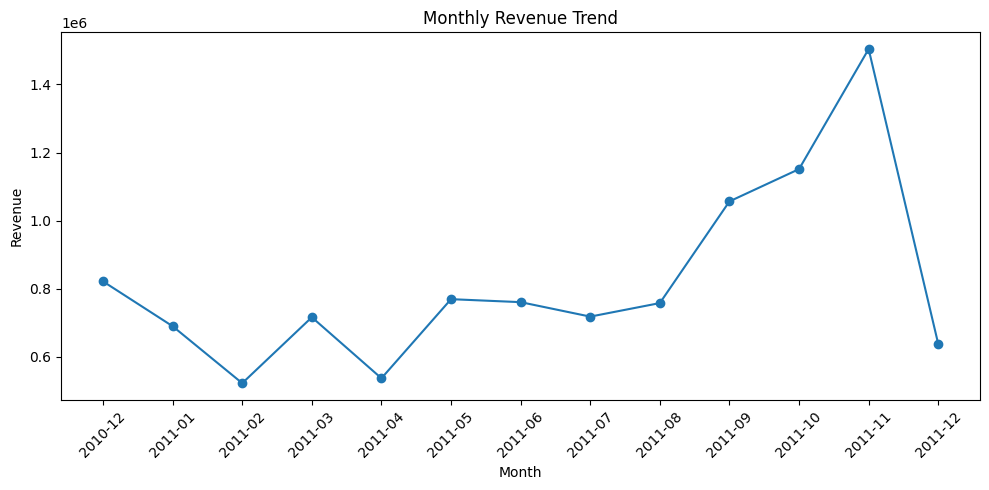

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_revenue["YearMonth"].astype(str),
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 8.2 Top Merchandise Products by Revenue

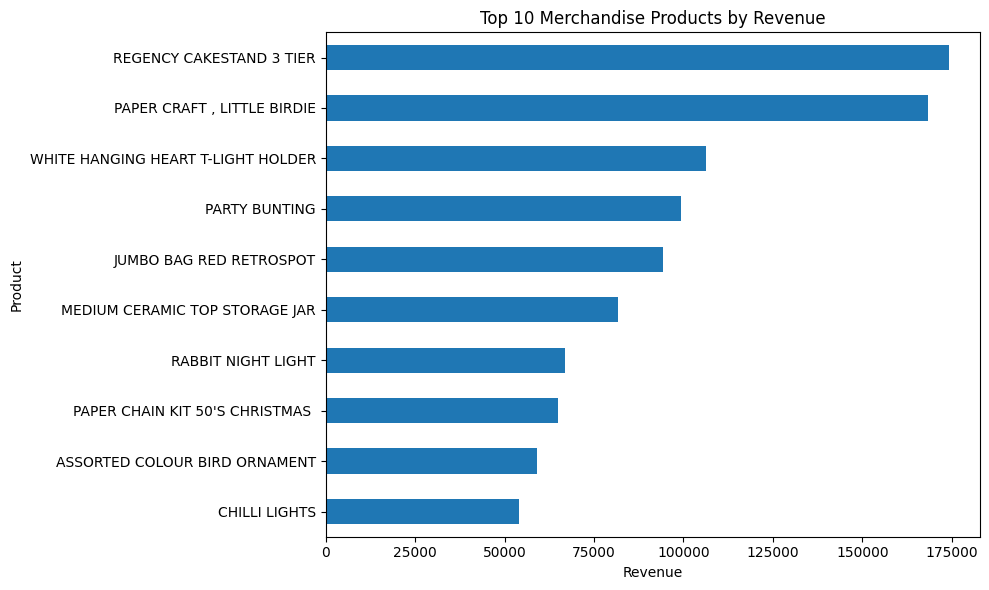

In [ ]:
top_merchandise_revenue.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Merchandise Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

### 8.3 Revenue by Weekday

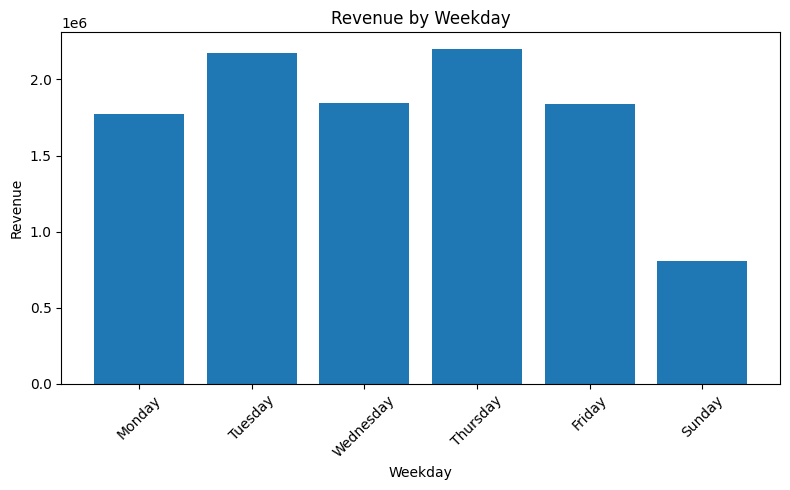

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    weekday_revenue["Weekday"],
    weekday_revenue["Revenue"]
)

plt.title("Revenue by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 8.4 Orders by Hour

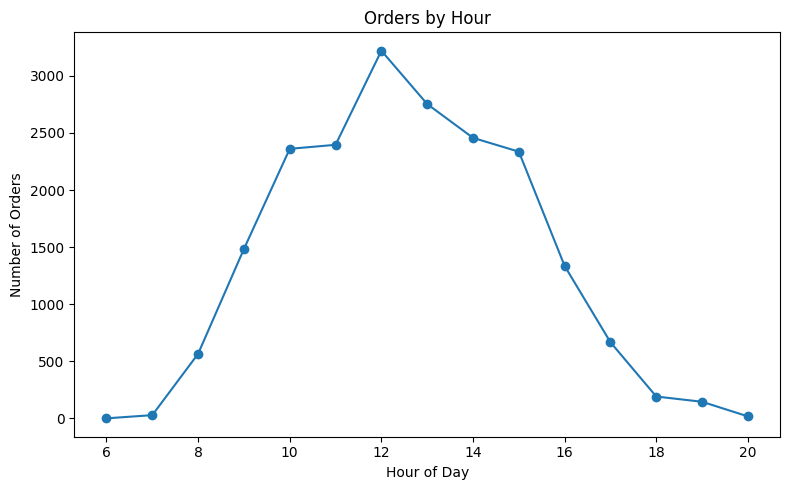

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    hourly_orders["Hour"],
    hourly_orders["Orders"],
    marker="o"
)

plt.title("Orders by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

## 9. Key Business Findings

1. The business generated approximately **£10.64 million** in revenue from **19,960 completed orders**.

2. A total of **4,338 identifiable customers** made purchases, with an average order value of approximately **£533**.

3. Revenue increased strongly during the later months of 2011, with **November 2011** recording the highest monthly revenue among the complete months in the dataset.

4. The **United Kingdom contributed approximately 84.6% of total revenue**, showing a high level of geographic concentration.

5. Approximately **65.6% of identifiable customers placed more than one order**, indicating a strong level of repeat purchasing behavior.

6. The **top 10 customers contributed approximately 17.3% of identifiable customer revenue**, showing meaningful revenue concentration among a small group of high-value customers.

7. Customer spending was highly right-skewed, with the mean spend substantially higher than the median, suggesting that a relatively small number of customers account for a large share of spending.

8. After excluding non-merchandise entries, **REGENCY CAKESTAND 3 TIER** emerged as one of the strongest merchandise products by revenue.

9. Order activity peaked around **12:00 PM**, indicating that late morning to early afternoon is the busiest purchasing period.

10. Cancelled invoices represented approximately **14.8% of all unique invoices**, highlighting a potentially significant operational area for further investigation.

## 10. Business Recommendations

1. **Strengthen customer retention**
   Since a large share of customers are repeat buyers, the business should consider loyalty programs, personalized offers, and targeted retention campaigns.

2. **Protect high-value customers**
   A small group of customers contributes a meaningful share of revenue. These customers should be monitored closely and supported through personalized communication, priority service, and retention-focused offers.

3. **Reduce geographic dependency**
   Because the United Kingdom generates the majority of revenue, the business should evaluate opportunities to expand in international markets that already show meaningful demand, such as the Netherlands, Germany, France, and EIRE.

4. **Investigate cancellation drivers**
   The relatively high cancellation rate should be analyzed further by product, customer, and time period to identify potential operational, product-quality, or fulfillment issues.

5. **Align marketing with peak activity**
   Since order activity is highest around midday, promotional campaigns and customer engagement activities may be more effective when scheduled around high-activity periods.

6. **Prioritize high-performing merchandise**
   Strong-performing products should receive greater attention in inventory planning, promotions, and cross-selling strategies.

7. **Develop customer segmentation**
   Because spending is highly concentrated among a small number of high-value customers, the business could benefit from segmenting customers based on spend and purchase frequency to support more targeted marketing strategies.

## 11. Conclusion

This project demonstrates how raw transactional data can be transformed into meaningful business insights through data cleaning, feature engineering, exploratory data analysis, and visualization.

The analysis identified important patterns in revenue performance, customer behavior, product performance, geographic concentration, purchasing activity, and cancellations.

The results suggest that the business has strong repeat purchasing behavior and a valuable base of high-spending customers, but it also shows significant dependence on the UK market and a notable level of order cancellations.

These insights can support better decision-making in customer retention, marketing, inventory planning, international growth, and operational improvement.